# 05 - Comprehensive Final Analysis (Model Stage)

## 📌 Objective
Final side-by-side audit of the Sales and Rental pipelines. We evaluate the effectiveness of our feature selection and redundancy elimination strategy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_theme(style="whitegrid")

sales_m = pd.read_parquet("../data/model/model_sales.parquet")
rentals_m = pd.read_parquet("../data/model/model_rentals.parquet")

print(f"✅ Sales Final Features: {len(sales_m.columns)}")
print(f"✅ Rentals Final Features: {len(rentals_m.columns)}")

✅ Sales Final Features: 31
✅ Rentals Final Features: 31


## 🔎 Deep Analysis: Feature Selection & Redundancy Audit
During the `data_builder.py` phase, we strategically dropped columns that were either redundant, leaky, or zero-variance. 

| Dropped Category | Example Columns | Justification |
| :--- | :--- | :--- |
| **Textual Redundancy** | `price_text`, `area_text` | Duplicate info already captured in float format. |
| **Target Leakage** | `price` | Predicted target is `price / area`; raw price would cause 1.0 correlation. |
| **Noise / High Card** | `url`, `title`, `listing_mode` | Meta-data with no predictive power for value. |
| **Temporal Leakage** | `scraped_at` | Model should be cross-sectional, not time-dependent for this iteration. |

In [ ]:
# Demonstrating the richness of the final feature set vs the raw input
final_cols = sales_m.columns.tolist()
print(f"Final Model Matrix Columns: {final_cols}")

Final Model Matrix Columns: ['price_text', 'area_text', 'city', 'bhk_text', 'listing_type', 'society_hint', 'description_raw', 'listing_mode', 'area', 'bedrooms', 'bathrooms', 'balcony', 'ready_to_move', 'is_luxury', 'is_gated_community', 'is_vastu_compliant', 'has_pool', 'has_gym', 'has_lift', 'sector', 'agent_name', 'is_individual', 'price_per_sqft', 'extracted_locality', 'latitude', 'longitude', 'h3_res8', 'h3_median_price', 'h3_listings_count', 'local_zscore', 'geo_confidence']


## 🔎 Deep Analysis: Parallel Market Comparison
Comparing the Log-Transformed intensity of both markets.

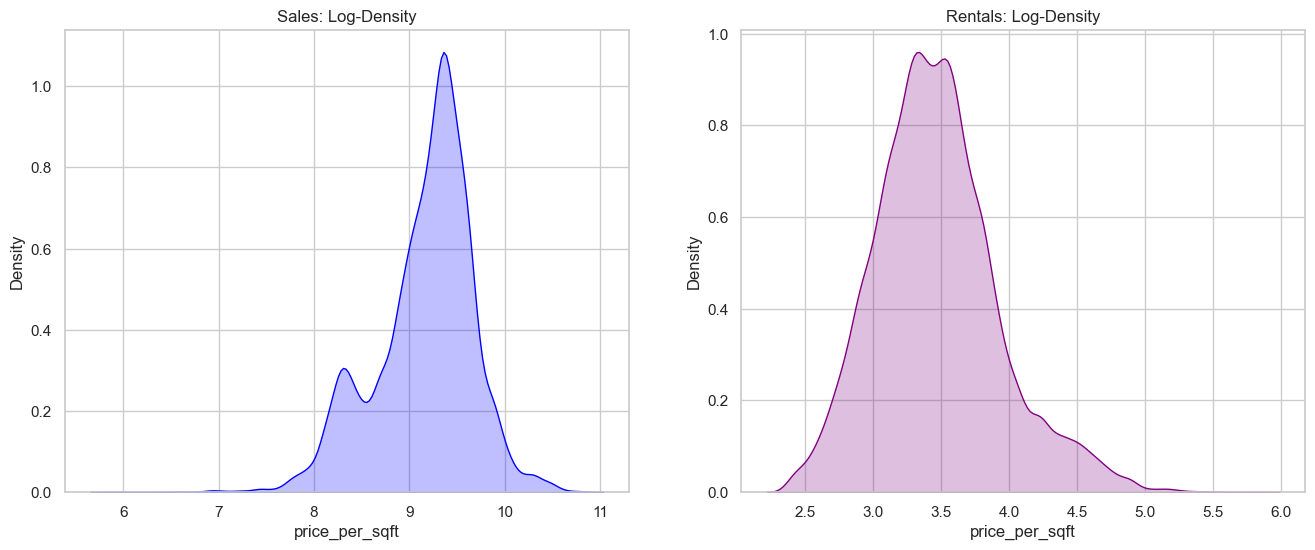

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(np.log1p(sales_m['price_per_sqft']), fill=True, ax=ax[0], color='blue', label='Sales')
sns.kdeplot(np.log1p(rentals_m['price_per_sqft']), fill=True, ax=ax[1], color='purple', label='Rentals')
ax[0].set_title("Sales: Log-Density")
ax[1].set_title("Rentals: Log-Density")
plt.show()